# ** Uber Fare Prediction using Regression Analysis**



In [1]:
import pandas as pd  # to read the data
import numpy as np   # to perform numerical operations
import seaborn as sns  # data visualisation
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression   
from sklearn.model_selection import train_test_split   
# from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score


In [2]:
# Ignore warnings messages 
import warnings 
warnings.filterwarnings('ignore')

1. **Read The Dataset**
   

In [3]:
df = pd.read_csv("uber.csv")
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


In [4]:
df.shape

(200000, 9)

In [5]:
# statistical summary
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


2) **HANDLING MISSING VALUES**

In [7]:
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [8]:
df.dropna(inplace=True)
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


**Remove Negative Fare**

In [9]:
df = df[df['fare_amount'] > 0]
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


**Fix Passenger Count**

In [10]:
df = df[(df['passenger_count'] >= 1) & (df['passenger_count'] <= 6)]
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


**Fix Latitude and Longitude**

In [11]:
df = df[
    (df['pickup_latitude'].between(-90, 90)) &
    (df['pickup_longitude'].between(-180, 180)) &
    (df['dropoff_latitude'].between(-90, 90)) &
    (df['dropoff_longitude'].between(-180, 180))]

df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06 UTC,-73.999817,40.738354,-73.999512,40.723217,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56 UTC,-73.994355,40.728225,-73.994710,40.750325,1
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00 UTC,-74.005043,40.740770,-73.962565,40.772647,1
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21 UTC,-73.976124,40.790844,-73.965316,40.803349,3
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00 UTC,-73.925023,40.744085,-73.973082,40.761247,5
...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00 UTC,-73.987042,40.739367,-73.986525,40.740297,1
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00 UTC,-73.984722,40.736837,-74.006672,40.739620,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00 UTC,-73.986017,40.756487,-73.858957,40.692588,2
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25 UTC,-73.997124,40.725452,-73.983215,40.695415,1


3) **Feature Engineering**



In [12]:
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])

In [13]:
df['year'] = df['pickup_datetime'].dt.year

df['month'] = df['pickup_datetime'].dt.month

df['day'] = df['pickup_datetime'].dt.day

df['hour'] = df['pickup_datetime'].dt.hour

df['day_of_week'] = df['pickup_datetime'].dt.dayofweek


In [14]:
df.head()

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10,6
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1,4
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0,0
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14,2


3.1 **Create Distance Feature**

**This calculates**
distance between pickup and drop location

Example:

Short ride → 2 km
Long ride → 15 km

Model understands:

More distance → more fare

In [15]:
df['distance_km'] = (
    ((df['pickup_latitude'] - df['dropoff_latitude'])**2 +
     (df['pickup_longitude'] - df['dropoff_longitude'])**2) ** 0.5
)

In [16]:
df


,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week,distance_km
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,0.015140
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,0.022103
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,0.053109
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,0.016528
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,0.051031
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10,6,0.001064
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1,4,0.022126
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0,0,0.142223
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14,2,0.033101


3.2  **Create Peak Hour Feature**

In [17]:
# Morning rush: 7–9
# Evening rush: 4–7

# If ride is in these hours:

# 1 = peak hour
# 0 = normal

df['peak_hour'] = df['hour'].apply(
    lambda x: 1 if (7 <= x <= 9 or 16 <= x <= 19) else 0)

df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week,distance_km,peak_hour
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,0.015140,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,0.022103,0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,0.053109,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,0.016528,1
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,0.051031,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10,6,0.001064,0
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1,4,0.022126,0
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0,0,0.142223,0
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14,2,0.033101,0


In [18]:
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week,distance_km,peak_hour
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,0.015140,1
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,0.022103,0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,0.053109,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,0.016528,1
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,0.051031,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10,6,0.001064,0
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1,4,0.022126,0
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0,0,0.142223,0
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14,2,0.033101,0


3.3  **Create Night Ride Feature**


In [19]:
# Night time: 10 PM → 5 AM
# Less availability → higher fare sometimes

df['night_ride'] = df['hour'].apply(
    lambda x: 1 if (x >= 22 or x <= 5) else 0)


In [22]:
df

,Unnamed: 0,key,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week,distance_km,peak_hour,night_ride
0,24238194,2015-05-07 19:52:06.0000003,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,0.015140,1,0
1,27835199,2009-07-17 20:04:56.0000002,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,0.022103,0,0
2,44984355,2009-08-24 21:45:00.00000061,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,0.053109,0,0
3,25894730,2009-06-26 08:22:21.0000001,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,0.016528,1,0
4,17610152,2014-08-28 17:47:00.000000188,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,0.051031,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,42598914,2012-10-28 10:49:00.00000053,3.0,2012-10-28 10:49:00+00:00,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10,6,0.001064,0,0
199996,16382965,2014-03-14 01:09:00.0000008,7.5,2014-03-14 01:09:00+00:00,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1,4,0.022126,0,1
199997,27804658,2009-06-29 00:42:00.00000078,30.9,2009-06-29 00:42:00+00:00,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0,0,0.142223,0,1
199998,20259894,2015-05-20 14:56:25.0000004,14.5,2015-05-20 14:56:25+00:00,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14,2,0.033101,0,0


In [20]:
df = df.drop(['pickup_datetime','key'],axis = 1)
df

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week,distance_km,peak_hour,night_ride
0,24238194,7.5,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,0.015140,1,0
1,27835199,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,0.022103,0,0
2,44984355,12.9,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,0.053109,0,0
3,25894730,5.3,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,0.016528,1,0
4,17610152,16.0,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,0.051031,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199995,42598914,3.0,-73.987042,40.739367,-73.986525,40.740297,1,2012,10,28,10,6,0.001064,0,0
199996,16382965,7.5,-73.984722,40.736837,-74.006672,40.739620,1,2014,3,14,1,4,0.022126,0,1
199997,27804658,30.9,-73.986017,40.756487,-73.858957,40.692588,2,2009,6,29,0,0,0.142223,0,1
199998,20259894,14.5,-73.997124,40.725452,-73.983215,40.695415,1,2015,5,20,14,2,0.033101,0,0


In [21]:
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0',axis=1)

df.head()

,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week,distance_km,peak_hour,night_ride
0,7.5,-73.999817,40.738354,-73.999512,40.723217,1,2015,5,7,19,3,0.015140,1,0
1,7.7,-73.994355,40.728225,-73.994710,40.750325,1,2009,7,17,20,4,0.022103,0,0
2,12.9,-74.005043,40.740770,-73.962565,40.772647,1,2009,8,24,21,0,0.053109,0,0
3,5.3,-73.976124,40.790844,-73.965316,40.803349,3,2009,6,26,8,4,0.016528,1,0
4,16.0,-73.925023,40.744085,-73.973082,40.761247,5,2014,8,28,17,3,0.051031,1,0


Most fares are low. 
Very few rides have high fare.


Insight:
Data is right-skewed.
Many cheap rides, few expensive ones.

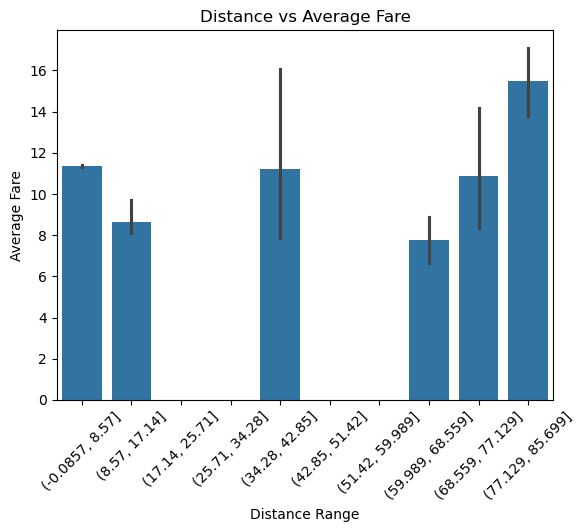

In [57]:
# Distance vs average fare

# Step 1: Create bins for distance
df['distance_bin'] = pd.cut(df['distance_km'], bins=10)

# Step 2: Create bar plot
plt.figure()

sns.barplot(
    x='distance_bin',
    y='fare_amount',
    data=df
)

plt.xticks(rotation=45)

plt.title("Distance vs Average Fare")
plt.xlabel("Distance Range")
plt.ylabel("Average Fare")

plt.show()

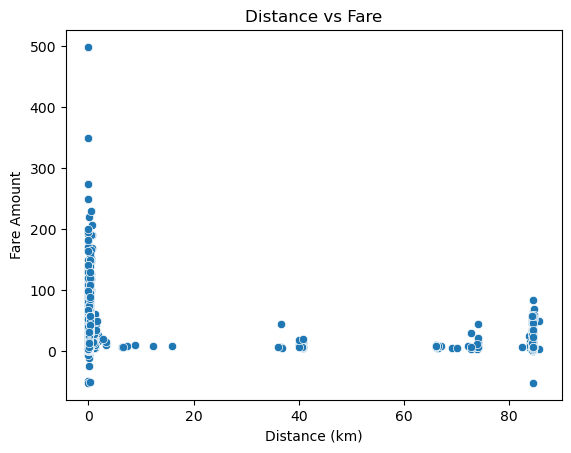

In [58]:
# Distance vs Fare

plt.figure()
sns.scatterplot(x='distance_km', y='fare_amount', data=df)
plt.title("Distance vs Fare")
plt.xlabel("Distance (km)")
plt.ylabel("Fare Amount")
plt.show()

In [ ]:
As distance increases → fare increases
Strong relationship between distance & Fare

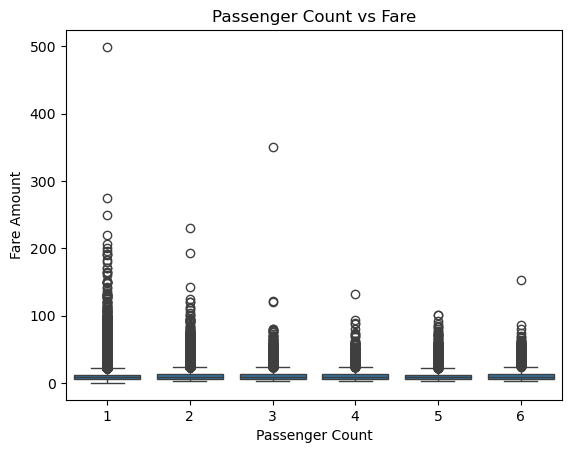

In [26]:
# passenger count vs Fare

plt.figure()
sns.boxplot(x='passenger_count', y='fare_amount', data=df)
plt.title("Passenger Count vs Fare")
plt.xlabel("Passenger Count")
plt.ylabel("Fare Amount")
plt.show()

 Median fare is almost same for all passenger counts.
 Some outliers present.
 Passenger count has very little impact on fare.

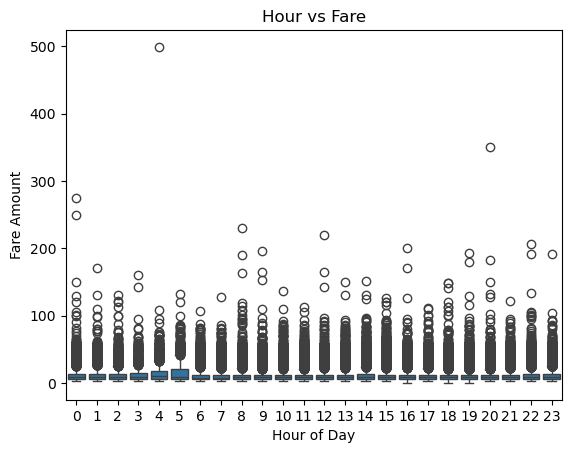

In [27]:
# Hour vs Fare


plt.figure()
sns.boxplot(x='hour', y='fare_amount', data=df)
plt.title("Hour vs Fare")
plt.xlabel("Hour of Day")
plt.ylabel("Fare Amount")
plt.show()

In [ ]:
Time affects fare moderately
Slightly higher fares at certain times
Peak hours may have higher fares

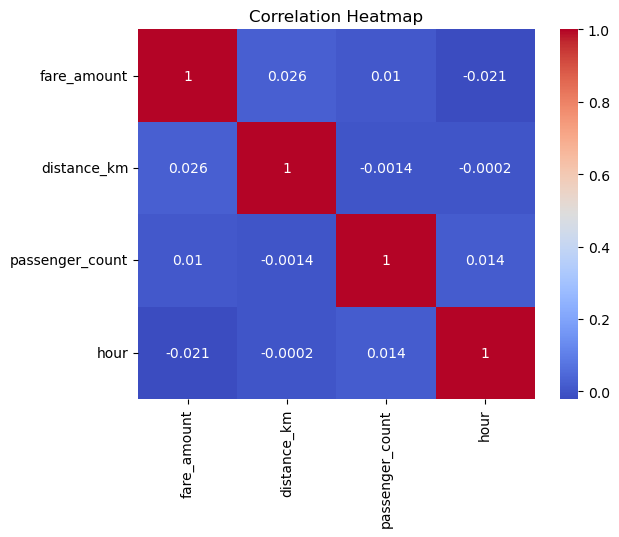

In [23]:
# Correlation Heatmap

plt.figure()

corr = df[['fare_amount','distance_km','passenger_count','hour']].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
distance_km - strongest relation with fare
passenger_count - very weak
hour - weak to moderate

INSIGHTS



The distribution of fare was right-skewed with presence of outliers. 
Scatter plot showed a strong positive relationship between distance and fare, making distance the most important feature.
Passenger count showed minimal impact, while time-based features had moderate influence.

4.  **Split the Dataset (Train / Test)**


In [22]:
from sklearn.model_selection import train_test_split
x = df.drop('fare_amount',axis=1)
y = df['fare_amount']

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2, random_state = 42)


In [23]:
x_train

,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,year,month,day,hour,day_of_week,distance_km,peak_hour,night_ride
136917,-73.988617,40.734785,-73.955850,40.676165,1,2013,4,28,3,6,0.067156,0,1
65526,-73.981753,40.762892,-73.991273,40.750373,1,2010,4,6,7,1,0.015728,1,0
16066,-74.001473,40.741185,-73.952330,40.819063,5,2010,11,28,15,6,0.092087,0,0
126487,-73.979360,40.752692,-73.982458,40.778046,1,2009,3,10,16,1,0.025543,1,0
174241,-73.997638,40.734703,-73.985367,40.740097,1,2010,7,28,16,2,0.013404,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
120325,-73.987175,40.743593,-73.865852,40.771015,1,2013,12,2,12,0,0.124383,0,0
104079,-73.904510,40.741697,-73.921725,40.737465,1,2012,2,29,14,2,0.017728,0,0
132418,-73.972171,40.761953,-73.995433,40.733478,1,2012,2,9,15,3,0.036769,0,0
147405,-73.985619,40.762936,-73.976387,40.764118,1,2015,6,26,9,4,0.009307,1,0


In [26]:
x_test.shape

(39852, 13)

In [27]:
y_train

136917    23.50
65526      6.10
16066     16.50
126487     9.10
174241     6.50
          ...  
120325    36.33
104079     6.10
132418    10.50
147405     5.50
122408     4.50
Name: fare_amount, Length: 159404, dtype: float64

In [28]:
y_test

157816    11.3
72490     68.3
23417      7.0
89511      3.5
98739     14.0
          ... 
137967     4.1
154242     7.3
193870     9.0
138606     6.0
511        7.7
Name: fare_amount, Length: 39852, dtype: float64

5. **Data Scaling/ Normalization**


In [29]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(x_train)

x_test = scaler.transform(x_test)


In [30]:
print(x_train)
print(x_train.shape)
print(x_test.shape)

[[-0.14210778  0.13294293 -0.13822024 ... -0.03718652 -0.72157313
   1.81377555]
 [-0.14145062  0.13752028 -0.14163068 ... -0.05080463  1.38586092
  -0.55133613]
 [-0.14333863  0.1339852  -0.13788134 ... -0.03058502 -0.72157313
  -0.55133613]
 ...
 [-0.14053323  0.13736736 -0.1420312  ... -0.045233   -0.72157313
  -0.55133613]
 [-0.14182071  0.13752738 -0.14019749 ... -0.05250476  1.38586092
  -0.55133613]
 [ 6.94161532 -6.50089111  6.9820834  ... -0.05496921 -0.72157313
   1.81377555]]
(159404, 13)
(39852, 13)


# **Correlation Analysis**


In [31]:
corr_df = df[['fare_amount', 'distance_km', 'passenger_count', 'hour', 'day_of_week']]

In [32]:
corr_matrix = corr_df.corr()
print(corr_matrix)

                 fare_amount  distance_km  passenger_count      hour  \
fare_amount         1.000000     0.026063         0.010184 -0.021482   
distance_km         0.026063     1.000000        -0.001420 -0.000203   
passenger_count     0.010184    -0.001420         1.000000  0.014496   
hour               -0.021482    -0.000203         0.014496  1.000000   
day_of_week         0.007222    -0.004682         0.035569 -0.086642   

                 day_of_week  
fare_amount         0.007222  
distance_km        -0.004682  
passenger_count     0.035569  
hour               -0.086642  
day_of_week         1.000000  


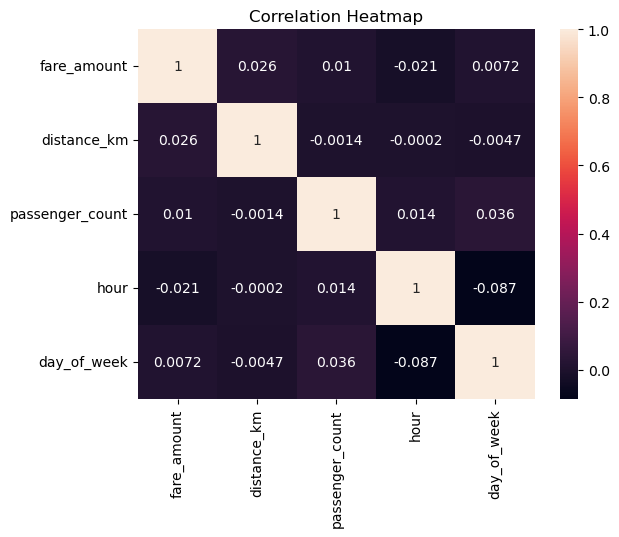

In [90]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.heatmap(corr_matrix, annot=True)

plt.title("Correlation Heatmap")
plt.show()

Train the Regression Model

# Linear Regression

In [38]:
model = LinearRegression()

model.fit(x_train , y_train)

LinearRegression()

# Make predictions

In [40]:
y_pred = model.predict(x_test)
print(y_pred)

[10.34779412 11.31529514 11.91012945 ... 12.22696806 12.49897373
  9.52459905]


# Evaluate Model

In [41]:
from sklearn.metrics import mean_absolute_error , mean_squared_error,r2_score

import numpy as np
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 5.98005248789676
MSE: 95.29281146921778
RMSE: 9.761803699584302
R2 Score: 0.017939845810184374


The Linear Regression model was first trained to predict the fare amount.
However, the R2 score indicates that the model does not capture the relationship well.
Therefore, a more powerful model such as Random Forest Regressor is used for better prediction performance.

# ** Train Random Forest Model**


In [91]:
# import Random Forest
from sklearn.ensemble import RandomForestRegressor

In [92]:
model = RandomForestRegressor()

model = model.fit(x_train, y_train)
model

RandomForestRegressor()

In [98]:
# Random Forest model training

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred_rf = model.predict(x_test)

mae = mean_absolute_error(y_test, y_pred_rf)
mse = mean_squared_error(y_test, y_pred_rf)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred_rf)

print("Random Forest MAE:", mae)
print("Random Forest MSE:", mse)
print("Random Forest RMSE:", rmse)
print("Random Forest R2 Score:", r2)

Random Forest MAE: 1.8979875982542878
Random Forest MSE: 17.952717214727716
Random Forest RMSE: 4.2370646932431555
Random Forest R2 Score: 0.8149844887122798


Since we are not getting proper accuracy we will train gradient boosting regressor

# **Train the Gradient Boosting Regressor**

In [93]:
# import gradient boosting regressor

from sklearn.ensemble import GradientBoostingRegressor



In [94]:
model = GradientBoostingRegressor(
    n_estimators=200,   # number of trees
    learning_rate=0.1,  # step size
    max_depth=5,
    random_state=42
)

model.fit(x_train, y_train)

GradientBoostingRegressor(max_depth=5, n_estimators=200, random_state=42)

# **Make predictions**


In [96]:
y_pred = model.predict(x_test)

# **Model Evaluation**


In [99]:
gb = GradientBoostingRegressor()

gb.fit(x_train, y_train)

y_pred_gb = gb.predict(x_test)

print("GB RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("GB R2:", r2_score(y_test, y_pred_gb))

GB RMSE: 4.369573218580183
GB R2: 0.8032313109919766


# **Fine Tuning The Model**



from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}

grid = GridSearchCV(
    model,
    param_grid,
    cv=3,
    scoring='r2'
)

grid.fit(x_train, y_train)

# ** get best model**

In [ ]:
print("Best Parameters:", grid.best_params_)

best_model = grid.best_estimator_

# ** evaluate best model**

In [ ]:
y_pred = best_model.predict(x_test)

from sklearn.metrics import r2_score

print("Best R2 Score:", r2_score(y_test, y_pred))

I used Gradient Boosting Regressor to improve prediction accuracy.
Unlike Random Forest, it builds trees sequentially, where each model corrects the previous errors. 
This helped achieve better performance and lower RMSE.”

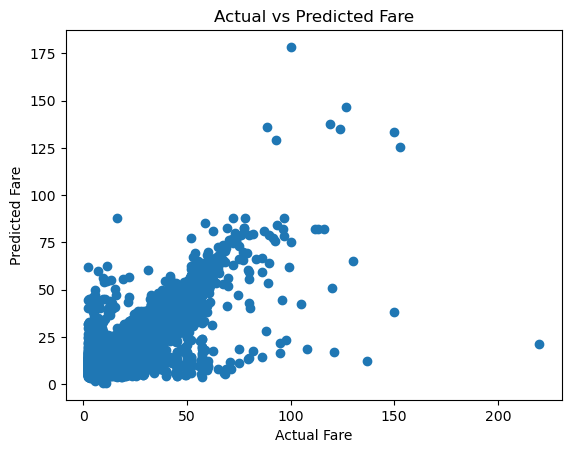

In [54]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Fare")

plt.show()

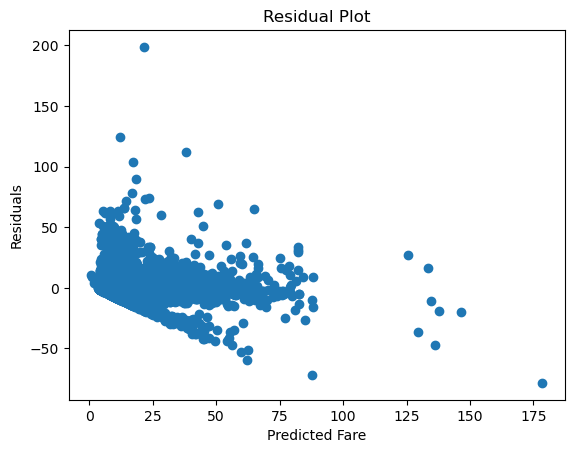

In [55]:
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


# **Interpret Feature Importance**


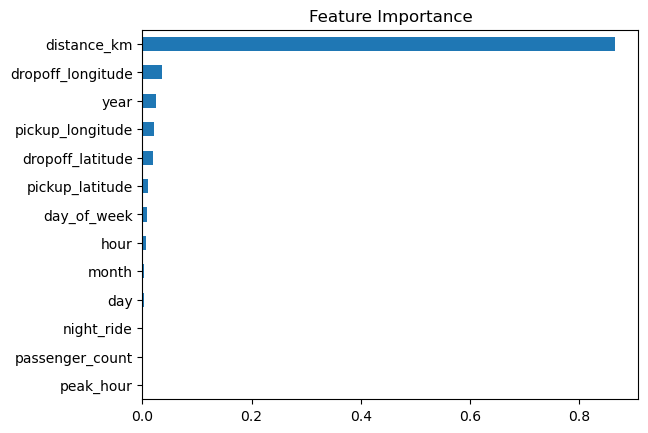

In [102]:
import pandas as pd
import matplotlib.pyplot as plt

importance = model.feature_importances_
features = x.columns

feature_importance = pd.Series(importance, index=features)

feature_importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

** Feature importance helps identify which variables influence the fare amount the most. From the analysis, distance between pickup and drop location is the most important feature.**

# ** Make Predictions On New Data **


In [106]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor()
model.fit(x_train, y_train)

GradientBoostingRegressor()

In [115]:
x_train = pd.DataFrame(x_train, columns = x.columns)

In [116]:
x_train.columns  

Index(['pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count', 'year', 'month', 'day', 'hour',
       'day_of_week', 'distance_km', 'peak_hour', 'night_ride'],
      dtype='object')

In [120]:
import pandas as pd

new_data = pd.DataFrame({
    'pickup_longitude': [-73.98],
    'pickup_latitude': [40.75],
    'dropoff_longitude': [-73.99],
    'dropoff_latitude': [40.76],
    'passenger_count': [2],
    'year': [2025],
    'month': [3],
    'day': [25],
    'day_of_week': [2],
    'hour': [18],
    'distance_km': [2.5],
    'peak_hour': [1],
    'night_ride': [0]
})

In [121]:
new_data = new_data[x.columns]

In [122]:
prediction = model.predict(new_data)

print("Predicted Fare:", prediction[0])

Predicted Fare: 136.6913647195956


# **Provide Recommendations To Uber**



In [ ]:
1) Optimize Pricing Based on Distance

Insight:
Distance is the most important factor

Recommendation:
Implement distance-based dynamic pricing

More accurate fare calculation
Transparent pricing for users.

In [ ]:
2)- Dynamic Pricing for Peak Hours

Insight:
Time (hour) affects fare moderately

Recommendation:
Use surge pricing during peak hours

Morning (7–9 AM)
Evening (5–8 PM)

Benefits:

Balance supply & demand
Increase driver earnings

In [ ]:
3)Improve Route Optimization
Insight:
Distance strongly affects fare

Recommendation:

Suggest:
Shortest routes
Traffic-aware navigation

Benefits:
Lower fare
Better user experience

In [ ]:
4)Use Machine Learning for Fare Prediction

Insight:
Gradient Boosting gave best results

Recommendation:
Deploy ML model for:

Real-time fare prediction
Demand forecasting

# ** FINAL REPORT**

This project successfully predicts Uber fares using machine learning.
Gradient Boosting provided the highest accuracy by capturing complex patterns in the data.
By performing data cleaning, feature engineering, and model comparison, I found that distance is the most significant factor and Gradient Boosting provides the best prediction performance.